<a href="https://colab.research.google.com/github/Ariel-Pineapple/qc-anomaly-detection-isolation-forest/blob/main/Exploratory_Data_Analysis_(EDA).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

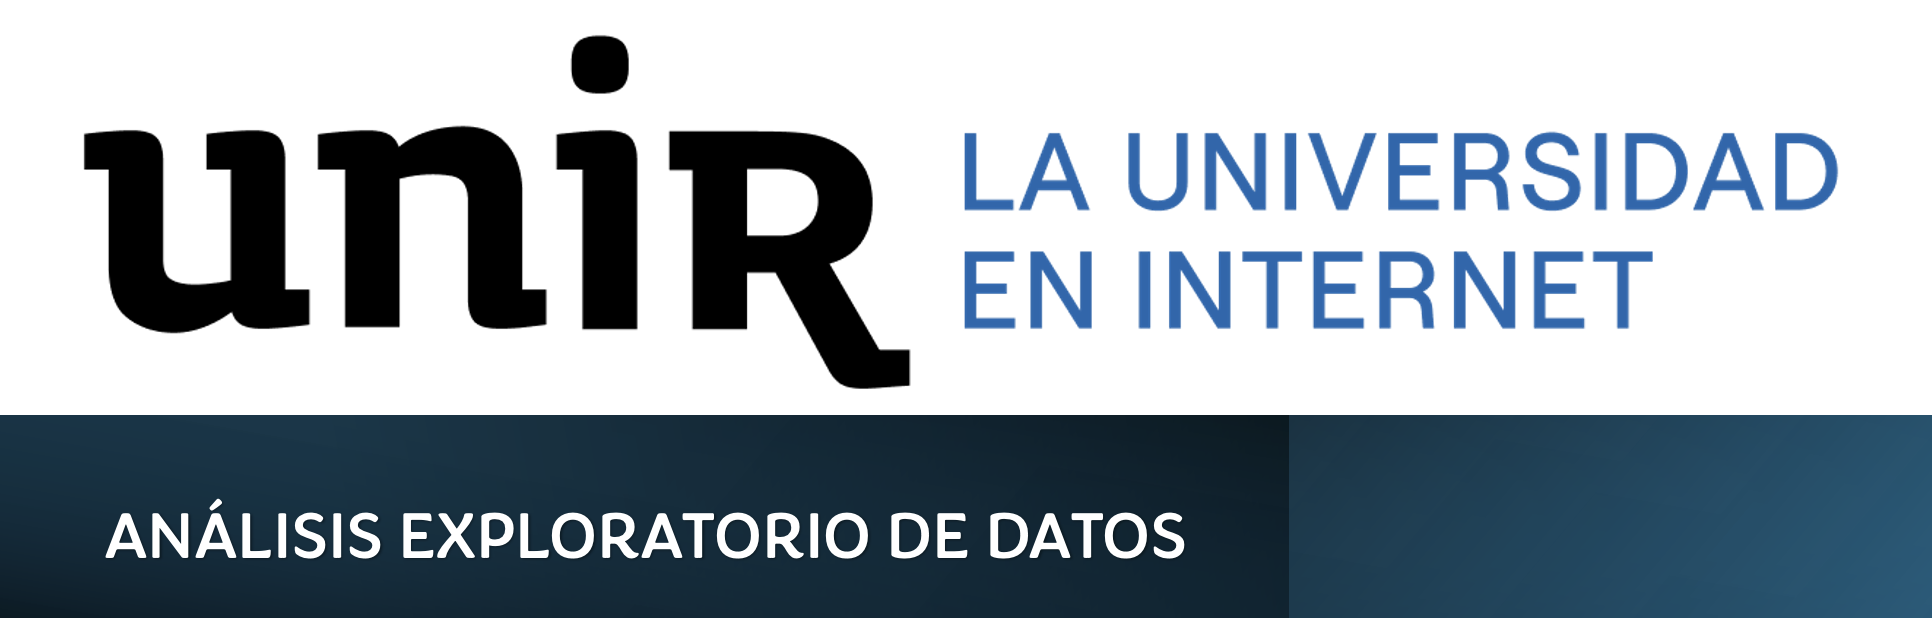

# Exploratory Data Analysis (EDA) del Dataset Sintético de Control de Calidad

**Proyecto:** Detección de anomalías en control de calidad de inmunoensayos  
**Modelo:** Isolation Forest  
**Autor(es):** Equipo 3004D  
**Fecha:** 2026  

---

## Objetivo

Analizar el comportamiento del dataset sintético generado para control de calidad en inmunoensayos, identificando patrones de normalidad, variabilidad y presencia de drifts, con el fin de validar su adecuación para el entrenamiento y evaluación de modelos de detección de anomalías.

---

## Descripción del dataset

El dataset contiene registros simulados de valores S/CO con las siguientes características:

- Serie temporal de mediciones
- Segmentos normales y con anomalías controladas
- Etiquetas de referencia (`estado_real`)
- Tipos de drift (`lineal`, `escalonado`, `aleatorio`)

# 1. Importación de Librerías

In [14]:
# Librerías principales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import autocorrelation_plot
import matplotlib.dates as mdates

# Configuración visual
plt.style.use("default")
sns.set_theme()

# Mostrar todas las columnas
pd.set_option("display.max_columns", None)

# 2. Carga del dataset

## Carga del dataset

En esta sección se carga el dataset sintético previamente generado, el cual simula el comportamiento de valores S/CO en procesos de control de calidad.

In [15]:
df = pd.read_csv("dataset_qc_sintetico.csv")

# Conversión de fecha a tipo datetime para análisis temporal
df["fecha"] = pd.to_datetime(df["fecha"])

df.head()

,id_registro,fecha,analito,lote,equipo,sco,estado_real,tipo_drift
0,1,2025-01-01,VIH,L001,E01,1.0248,0,normal
1,2,2025-01-02,VIH,L001,E01,0.9931,0,normal
2,3,2025-01-03,VIH,L001,E01,1.0324,0,normal
3,4,2025-01-04,VIH,L001,E01,1.0762,0,normal
4,5,2025-01-05,VIH,L001,E01,0.9883,0,normal


# 3. Inspección General


## Inspección general de la estructura del dataset

Se revisa la dimensionalidad, tipos de datos y presencia de valores nulos.

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   id_registro  360 non-null    int64         
 1   fecha        360 non-null    datetime64[ns]
 2   analito      360 non-null    object        
 3   lote         360 non-null    object        
 4   equipo       360 non-null    object        
 5   sco          360 non-null    float64       
 6   estado_real  360 non-null    int64         
 7   tipo_drift   360 non-null    object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 22.6+ KB


In [17]:
df.describe()
df.isnull().sum()

,0
id_registro,0
fecha,0
analito,0
lote,0
equipo,0
sco,0
estado_real,0
tipo_drift,0


### Interpretación inicial
El dataset contiene 360 registros y 8 variables, sin valores nulos. La variable `fecha` se encuentra en formato temporal, lo que permite analizar tendencias y comportamiento secuencial. Las variables `estado_real` y `tipo_drift` constituyen etiquetas de referencia para la validación posterior del modelo.

# 4. Distribución de la variable S/CO


## Distribución de los valores S/CO

Se analiza la distribución de los valores para identificar sesgos, dispersión y posibles desviaciones respecto a un comportamiento esperado.

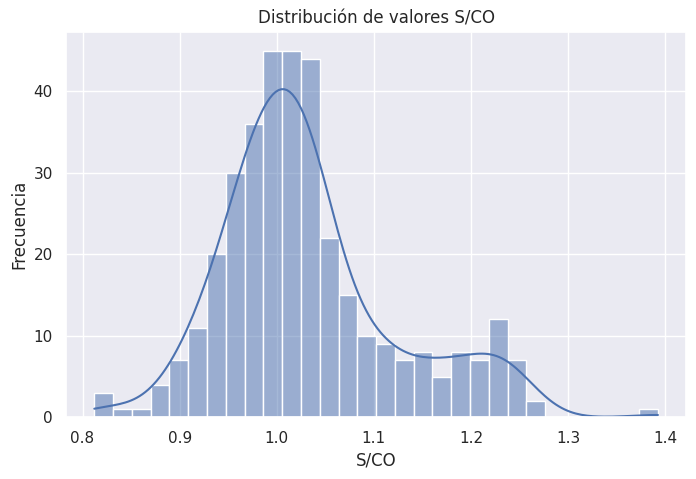

In [4]:
plt.figure(figsize=(8,5))
sns.histplot(df["sco"], bins=30, kde=True)
plt.title("Distribución de valores S/CO")
plt.xlabel("S/CO")
plt.ylabel("Frecuencia")
plt.show()

In [18]:
df.groupby("estado_real")["sco"].describe()

,count,mean,std,min,25%,50%,75%,max
estado_real,,,,,,,,
0,240.0,1.000273,0.045902,0.8690,0.967375,1.0009,1.031475,1.1360
1,120.0,1.094298,0.119922,0.8121,1.015900,1.1098,1.190700,1.3926


### Interpretación de la distribución
La distribución general de los valores S/CO muestra una concentración principal alrededor de 1.0, con dispersión moderada y una cola hacia valores mayores. Esto es consistente con la presencia de segmentos anómalos inyectados. La comparación descriptiva entre registros normales y anómalos permite anticipar diferencias relevantes para la detección automática.

# 5. Serie temporal

## Análisis temporal de los valores S/CO

Se visualiza la evolución de los valores S/CO a lo largo del tiempo para identificar patrones, tendencias y posibles anomalías.

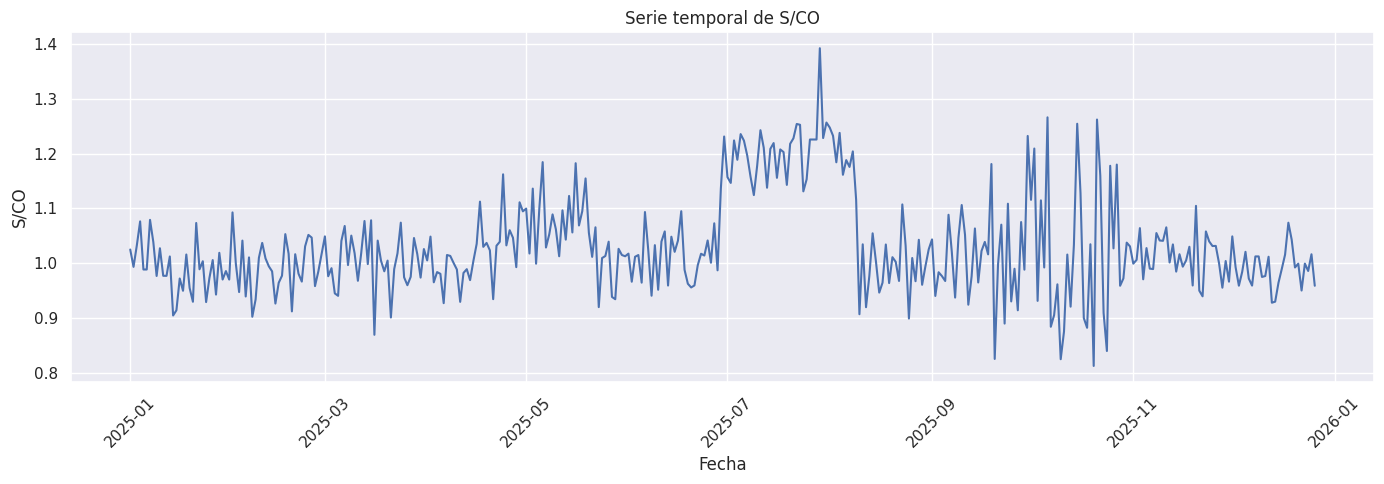

In [19]:
plt.figure(figsize=(14,5))
plt.plot(df["fecha"], df["sco"], linewidth=1.5)
plt.title("Serie temporal de S/CO")
plt.xlabel("Fecha")
plt.ylabel("S/CO")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

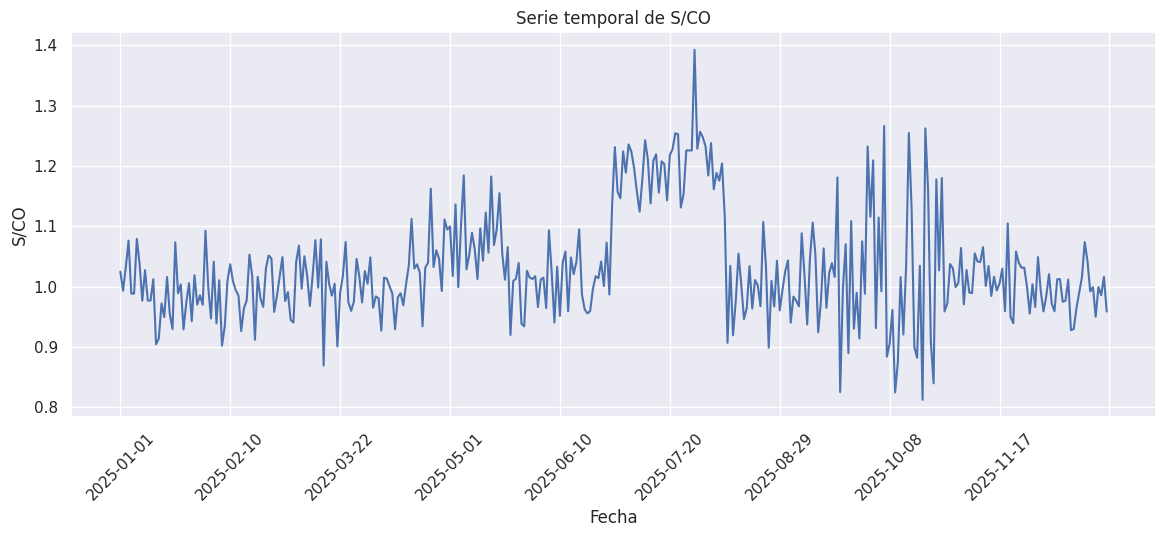

In [12]:
plt.figure(figsize=(14,5))
plt.plot(df["fecha"], df["sco"])
plt.title("Serie temporal de S/CO")
plt.xlabel("Fecha")
plt.ylabel("S/CO")

plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(10))

plt.show()

### Interpretación temporal
La serie temporal permite observar un comportamiento estable en los segmentos normales y alteraciones visibles en los tramos donde se inyectaron drifts. Esta visualización confirma que el dataset conserva estructura secuencial y resulta adecuado para análisis orientados a detección temprana de anomalías.

6. Identificación de anomalías reales


## Identificación de segmentos anómalos

Se resaltan los puntos etiquetados como anomalías para validar la coherencia del dataset sintético.

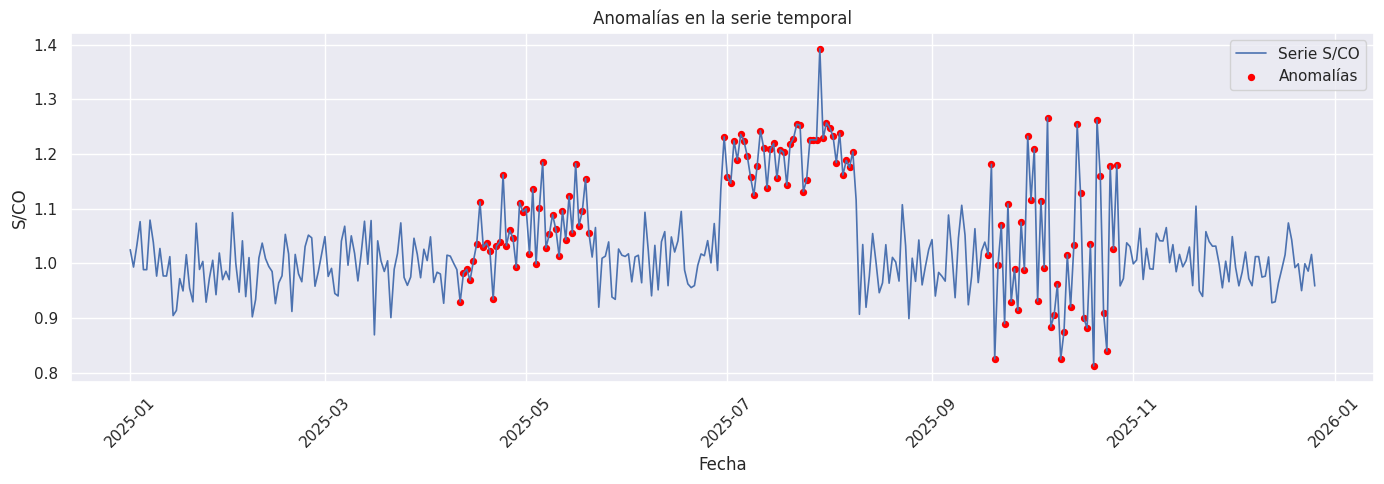

In [20]:
plt.figure(figsize=(14,5))
plt.plot(df["fecha"], df["sco"], label="Serie S/CO", linewidth=1.2)

anomalias = df[df["estado_real"] == 1]
plt.scatter(anomalias["fecha"], anomalias["sco"], color="red", label="Anomalías", s=18)

plt.title("Anomalías en la serie temporal")
plt.xlabel("Fecha")
plt.ylabel("S/CO")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)

plt.legend()
plt.tight_layout()
plt.show()

### Interpretación de anomalías
Los registros etiquetados como anómalos se concentran en segmentos específicos de la serie, lo que confirma que las alteraciones fueron inyectadas de forma controlada y no aleatoria en toda la muestra. Esto fortalece la utilidad del dataset como base para evaluación supervisada del desempeño del modelo.

# 7. Distribución por tipo de drift

## Distribución de tipos de drift

Se analiza la proporción de cada tipo de anomalía en el dataset.

In [21]:
conteo_drift = df["tipo_drift"].value_counts()
conteo_drift

,count
tipo_drift,
normal,240
lineal,40
escalonado,40
aleatorio,40


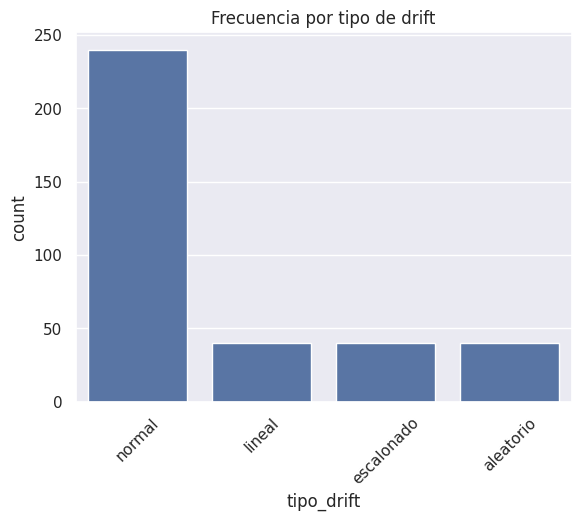

In [22]:
sns.countplot(data=df, x="tipo_drift")
plt.title("Frecuencia por tipo de drift")
plt.xticks(rotation=45)
plt.show()

### Interpretación por tipo de drift
La composición del dataset incluye 240 registros normales y 120 registros anómalos distribuidos de manera equilibrada entre drift lineal, escalonado y aleatorio. Esta proporción favorece el análisis comparativo y evita que una sola categoría domine el comportamiento global del conjunto.

# 8. Comparación normal vs anómalo

## Comparación entre comportamiento normal y anómalo

Se evalúan diferencias en distribución entre datos normales y anómalos.

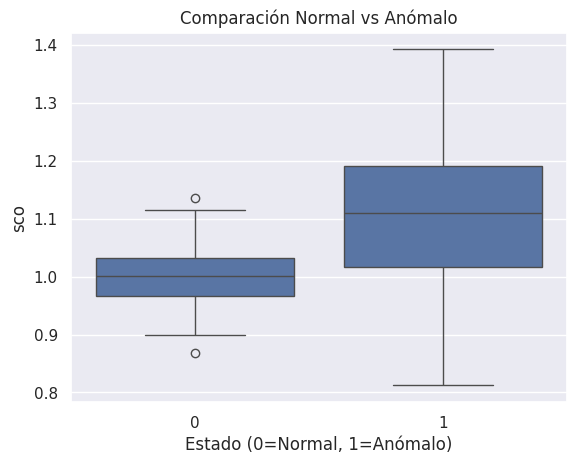

In [10]:
sns.boxplot(data=df, x="estado_real", y="sco")
plt.title("Comparación Normal vs Anómalo")
plt.xlabel("Estado (0=Normal, 1=Anómalo)")
plt.show()

In [23]:
df.groupby("estado_real")["sco"].agg(["mean", "std", "min", "max", "median"])

,mean,std,min,max,median
estado_real,,,,,
0,1.000273,0.045902,0.8690,1.1360,1.0009
1,1.094298,0.119922,0.8121,1.3926,1.1098


### Interpretación comparativa
Los registros anómalos presentan mayor dispersión y valores extremos más pronunciados que los registros normales. Esta diferencia sugiere que existe separabilidad parcial en el espacio de características, lo cual resulta favorable para la detección de anomalías mediante métodos no supervisados.

# 9. Análisis por lote


## Análisis por lote

Se analiza la variabilidad de los valores S/CO en función del lote.

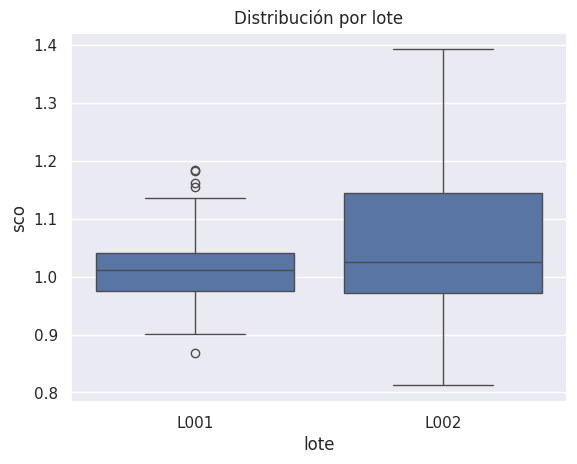

In [11]:
sns.boxplot(data=df, x="lote", y="sco")
plt.title("Distribución por lote")
plt.show()

In [24]:
df.groupby("lote")["sco"].agg(["mean", "std", "min", "max", "median"])

,mean,std,min,max,median
lote,,,,,
L001,1.011895,0.055448,0.8690,1.1845,1.01230
L002,1.051334,0.111663,0.8121,1.3926,1.02605


### Interpretación por lote
La comparación por lote permite identificar diferencias en nivel central y dispersión de los valores S/CO. Este comportamiento justifica la inclusión de la variable `lote` como contexto relevante para el modelado posterior, especialmente en escenarios donde el drift pudiera asociarse a cambios de reactivo.

## 10. Análisis de autocorrelación

Se analiza la dependencia temporal de la serie S/CO para identificar si existen patrones secuenciales que justifiquen el uso de variables derivadas basadas en ventanas temporales.

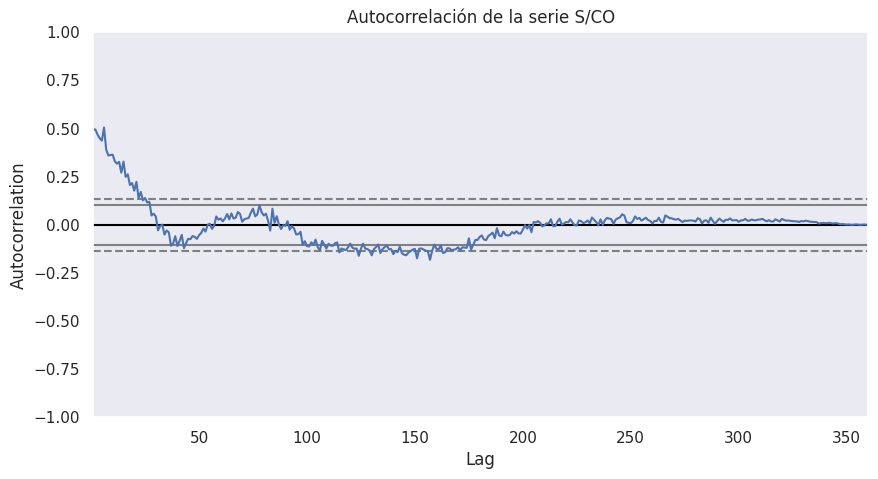

In [25]:
plt.figure(figsize=(10,5))
autocorrelation_plot(df["sco"])
plt.title("Autocorrelación de la serie S/CO")
plt.show()

### Interpretación de autocorrelación
La presencia de autocorrelación en la serie sugiere que los valores actuales conservan relación con observaciones previas. Este hallazgo respalda la construcción posterior de variables derivadas como medias móviles, desviaciones móviles y deltas temporales para enriquecer el modelo de detección de anomalías.

## 11. Conclusiones del EDA

A partir del análisis exploratorio realizado, se concluye que el dataset sintético presenta una estructura coherente con el objetivo del proyecto. La serie temporal conserva segmentos normales y anómalos claramente diferenciables, con distribución controlada de tipos de drift y ausencia de valores faltantes.

Asimismo, se identificó que los registros anómalos presentan mayor dispersión que los normales, y que existe dependencia temporal y variabilidad asociada al lote, lo cual justifica la generación posterior de variables derivadas orientadas al modelado.

En conjunto, estos hallazgos validan la utilidad del dataset sintético como base experimental para implementar el baseline estadístico, construir features temporales y entrenar el modelo de detección de anomalías.

## Limitaciones

- Los datos son simulados y no reflejan completamente la complejidad clínica real.
- No se consideran variables externas (temperatura, operador, calibración).